# Maaslin tutorial
## Introduction
In this tutorial, we will learn how to use MaAsLin2 to build a linear model to identify multivariable associations of microbiome features and a variable of interest (e.g. disease phenotype). We will work on the IBD cohort from the Human Microbiome Project 2 (HMP2), for which a large number of longitudinal metagenomic datasets are available for both IBD patients and non-IBD controls.

### Learning objective

* Understand the basic concepts of a general linear model

>>1 Fixed effects

>>2 Random effects

>>3 Define the reference group for the association testing of your variable of interest

* Be able to run MaAsLin2 on a multi-omics data set (taxonomic profile, functional profiles, etc)

* Understand the major output files of MaAsLin2



### Import libraries
Please make sure that you have run through the "test_setup_R_env.ipynb" file to install the packages

In [1]:
# 3 min to load for vegan,fossil,tidyverse
library(Maaslin2)
library(tidyverse)
library(vegan)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute



### Create a folder to save the output files


In [2]:
# maaslin_root = "/content/drive/MyDrive/workshop_June2023/R_MaAsLin2_tutorial"
maaslin_root = "/biodata/resources/day2_lab1"

###Load the relative abundance data table

In [3]:
input_data = system.file("extdata", "HMP2_taxonomy.tsv", package="Maaslin2")
df_input_data = read.table(file = input_data, header = TRUE, sep = "\t", row.names = 1, stringsAsFactors = FALSE)
# show the first 5 rows and columns
# each row is a sample, each column is a species
df_input_data[1:5, 1:5]

,Bifidobacterium.adolescentis,Bifidobacterium.bifidum,Bifidobacterium.longum,Bifidobacterium.pseudocatenulatum,Collinsella.aerofaciens
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CSM5FZ4M,0.0000000,0,0.0000000,0,0.0000000
CSM5MCUO,0.0002803,0,0.0002857,0,0.0002506
CSM5MCVL,0.0000000,0,0.0000000,0,0.0006440
CSM5MCVN,0.0000000,0,0.0000000,0,0.0000079
CSM5MCW6,0.0000000,0,0.0000000,0,0.0000000


### Load the metadata


In [4]:
input_metadata = system.file("extdata", "HMP2_metadata.tsv", package="Maaslin2") # metadata file
df_input_metadata = read.table(file = input_metadata, header = TRUE, sep = "\t", row.names = 1, stringsAsFactors = FALSE)
# show the first 5 rows of the metadata table
df_input_metadata[1:5, ]

,site,age,diagnosis,subject,antibiotics,dysbiosis_binary,dysbiosis,dysbiosisnonIBD,dysbiosisUC,dysbiosisCD,collection
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>
CSM5FZ3N_P,Cedars-Sinai,43,CD,C3001,No,No,0.7923148,No,No,No,1
CSM5FZ3R_P,Cedars-Sinai,43,CD,C3001,No,No,0.8379234,No,No,No,2
CSM5FZ3T_P,Cedars-Sinai,76,CD,C3002,No,Yes,0.9242969,No,No,Yes,1
CSM5FZ3V_P,Cedars-Sinai,43,CD,C3001,No,No,0.8304005,No,No,No,4
CSM5FZ3X_P,Cedars-Sinai,76,CD,C3002,No,Yes,0.9109670,No,No,Yes,2


# A quick introduction to running MaAsLin2
MaAsLin2 is based on a General Linear Model to determine associations between microbial features and metadata variables of interest.

> **Microbial features** can be species-level relative abundance profile, gene expression profile, metabolite abundance table etc.

> **Metadata variables** can be disease state, antibiotics usage, age etc. These features can be included as "fixed effects" or "random effects" in the general linear model. "Fixed effects" include your variable of interest as well as covariates that may impact the microbiome profiles. "Random effects" can account for inter-independency of samples in the dataset. For example, samples that were collected from the same patients in a longitudinal study.

Two types of variables:

> **Categorical variables**, such as disease state and gender

> **Numerical variables**, such as age (discrete) and BMI (continous)

Further information on Linear Mixed models can be found [here](https://stats.oarc.ucla.edu/other/mult-pkg/introduction-to-linear-mixed-models/) and [here](https://statmodeling.stat.columbia.edu/2005/01/25/why_i_dont_use/).

**First**, we will look at how to include categorical variables as fixed effects, while accounting for random effects.
Current model:
* Fixed effects
>> diagnosis [ref: nonIBD]
* Random effects
>> subject

When using a categorical variable as a fixed effect, we need to specify a reference group against which all other groups will be compared. Here, we set the "nonIBD" group as a reference and compare it against both IBD groups [Crohn's disease = CD and Ulcerative colitis = UC].

To set the reference, we need to pass in a list to the MaAsLin2 argument reference. Each element in the list sets a reference for one variable from the fixed effects. The format is "variable,reference_group". In this example, we are using "diagnosis,nonIBD" to set "nonIBD" as the reference group for the "diagnosis" variable.

Next, we set "subject" as a random effect, since this is a longitudinal study with multiple samples from the same patient (subject). By setting "subject" as a random effect, the linear model will take this dependency into account.

In [5]:
# The output folder
output_dir_1 = sprintf("%s/%s",maaslin_root,"demo_output1")

# "diagnosis" is a categorical variable, which contains the factors "CD", "UC", "nonIBD"
# we include basic filtering and only keep species which are present in at least 10% of the samples with a relative abundance of >0.01%

fit_data_1 = Maaslin2(
    input_data = df_input_data,
    input_metadata = df_input_metadata,
    output = output_dir_1,
    fixed_effects = c("diagnosis"),
    reference = c("diagnosis,nonIBD"),
    random_effects = c("subject"),
    min_prevalence = 0.1,
    min_abundance = 0.0001)

[1] "Warning: Deleting existing log file: /biodata/resources/day2_lab1/demo_output1/maaslin2.log"
2025-10-06 12:52:33.365693 INFO::Writing function arguments to log file
2025-10-06 12:52:33.382141 INFO::Verifying options selected are valid
2025-10-06 12:52:33.413922 INFO::Determining format of input files
2025-10-06 12:52:33.414803 INFO::Input format is data samples as rows and metadata samples as rows
2025-10-06 12:52:33.417587 INFO::Formula for random effects: expr ~ (1 | subject)
2025-10-06 12:52:33.41837 INFO::Formula for fixed effects: expr ~  diagnosis
2025-10-06 12:52:33.4193 INFO::Filter data based on min abundance and min prevalence
2025-10-06 12:52:33.419828 INFO::Total samples in data: 1595
2025-10-06 12:52:33.42035 INFO::Min samples required with min abundance for a feature not to be filtered: 159.500000
2025-10-06 12:52:33.423326 INFO::Total filtered features: 3
2025-10-06 12:52:33.423943 INFO::Filtered feature names from abundance and prevalence filtering: Bacteroides.sal

### This task will take a few minutes to finish. The output files are located in the folder **R_MaAsLin2_tutorial/output1**. Inspect the two pdf files containing the main outputs by clicking on the files from the google drive:
* heatmap.pdf
* diagnosis.pdf

The "heatmap.pdf" summarizes all significant associations across all variables [see figure below]. The color indicates the direction of the association: red is a positive and blue a negative association.
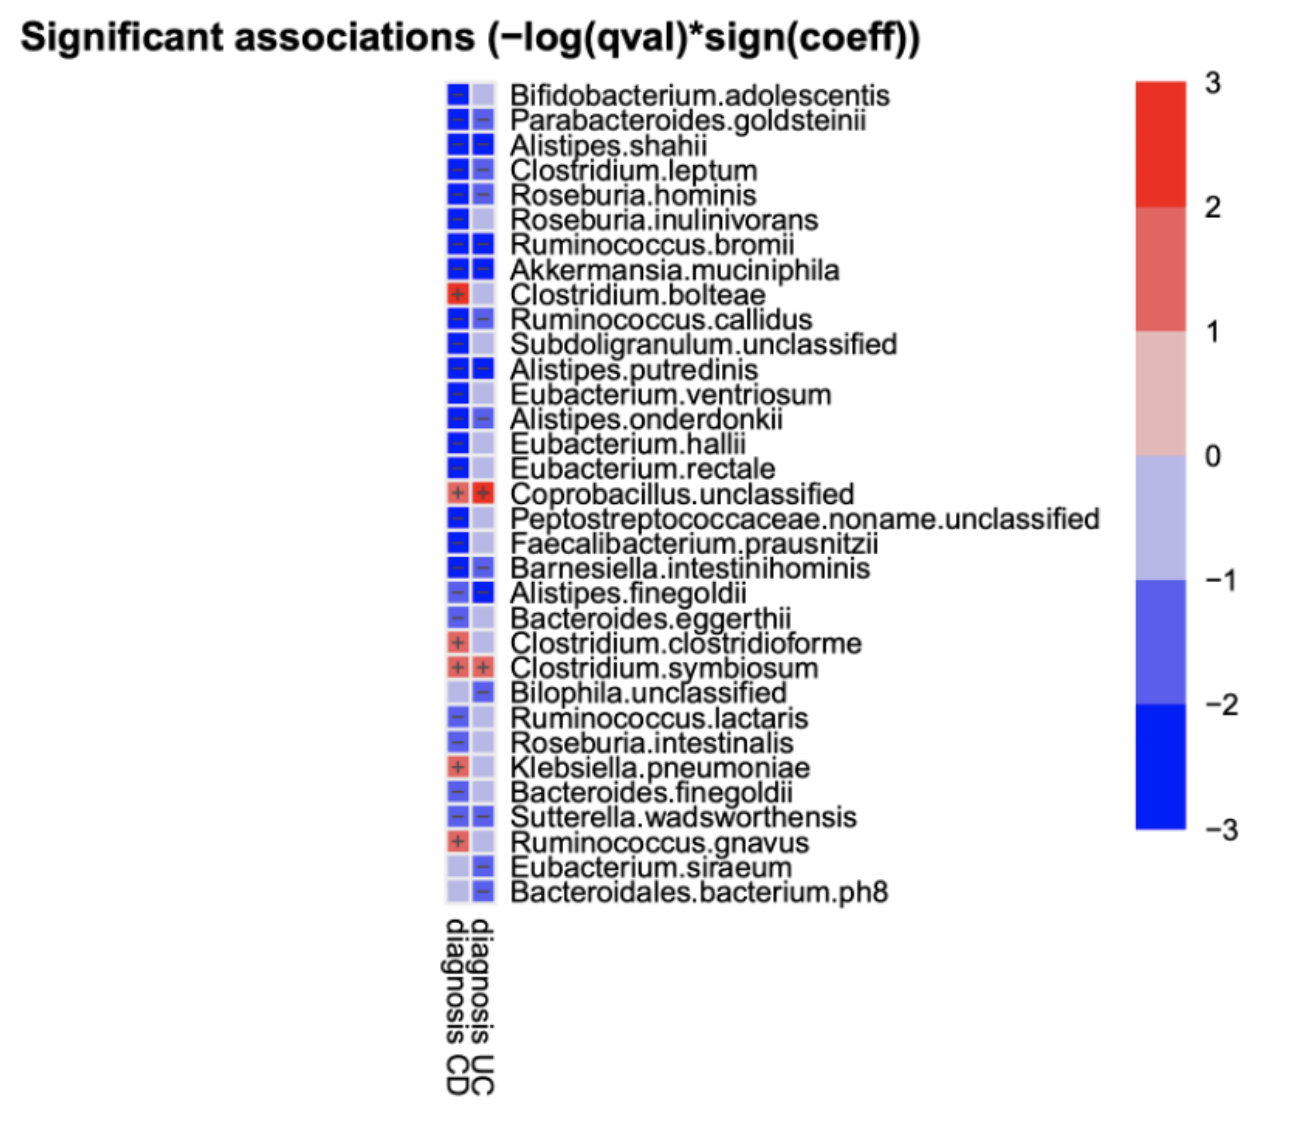

### Now we will take a closer look at the disease-associated species in the "diagnosis.pdf" file:

* FDR: false discovery rate

* Coefficient: the coefficient from the linear model. A positive value indicates a positive association. A negative value indicates a negative association. A larger absolute value implies a bigger change.

* Value: indicates the group that is significantly different from the reference.

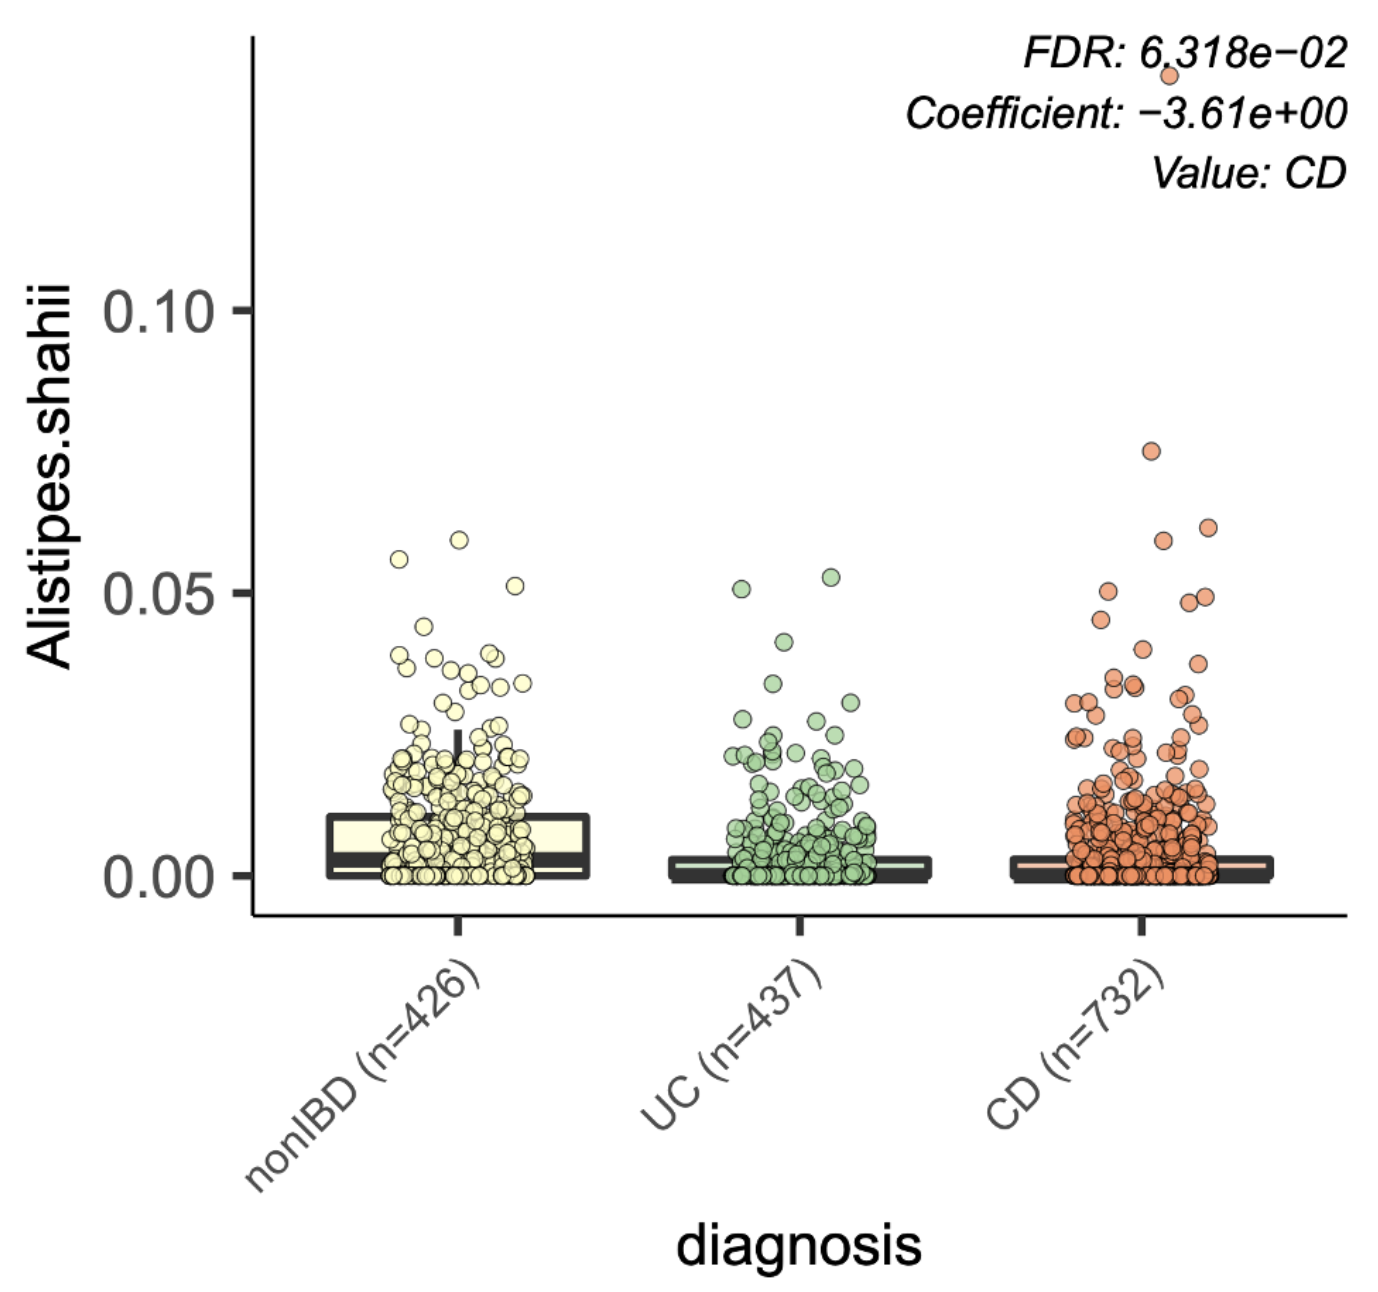

### Next, we will add the continuous variable dysbiosis as a fixed effects.
Current model:

* Fixed effects

>> diagnosis [ref: nonIBD]

>> dysbiosis

* Random effects
>> subject id

You can pass multiple variables to the argument "fixed_effects". Here, we add an additional variable into our analysis.

**Definition**: The dysbiosis score is a quantitative measurement of how much an observed microbial community deviates from the microbial community expected from the healthy control group. It has a value in the range between 0 and 1. The larger the dysbiosis score, the further away the sample deviates from the control samples. For more information: [Jason Lloyd-Price et al. 2019].

In [6]:
output_dir_2 = sprintf("%s/%s",maaslin_root,"demo_output2")

# Similar to our previous MaAsLin2 run with the addition of "dysbiosis" to the fixed_effects
fit_data_1 = Maaslin2(
    input_data = df_input_data,
    input_metadata = df_input_metadata,
    output = output_dir_2,
    fixed_effects = c("diagnosis","dysbiosis"),
    reference = c("diagnosis,nonIBD"),
    random_effects = c("subject"),
    min_prevalence = 0.1,
    min_abundance = 0.0001)

[1] "Warning: Deleting existing log file: /biodata/resources/day2_lab1/demo_output2/maaslin2.log"
2025-09-30 12:18:52.256697 INFO::Writing function arguments to log file
2025-09-30 12:18:52.390816 INFO::Verifying options selected are valid
2025-09-30 12:18:52.399223 INFO::Determining format of input files
2025-09-30 12:18:52.403642 INFO::Input format is data samples as rows and metadata samples as rows
2025-09-30 12:18:52.423914 INFO::Formula for random effects: expr ~ (1 | subject)
2025-09-30 12:18:52.430409 INFO::Formula for fixed effects: expr ~  diagnosis + dysbiosis
2025-09-30 12:18:52.436082 INFO::Filter data based on min abundance and min prevalence
2025-09-30 12:18:52.440247 INFO::Total samples in data: 1595
2025-09-30 12:18:52.444714 INFO::Min samples required with min abundance for a feature not to be filtered: 159.500000
2025-09-30 12:18:52.455283 INFO::Total filtered features: 3
2025-09-30 12:18:52.4595 INFO::Filtered feature names from abundance and prevalence filtering: B

`geom_smooth()` using formula = 'y ~ x'


2025-09-30 12:19:00.002896 INFO::Creating scatter plot for continuous data, dysbiosis vs Subdoligranulum.unclassified


`geom_smooth()` using formula = 'y ~ x'


2025-09-30 12:19:00.322494 INFO::Creating scatter plot for continuous data, dysbiosis vs Bacteroides.uniformis


...

2025-09-30 12:19:17.138618 INFO::Creating scatter plot for continuous data, dysbiosis vs Akkermansia.muciniphila


`geom_smooth()` using formula = 'y ~ x'


2025-09-30 12:19:17.357226 INFO::Creating scatter plot for continuous data, dysbiosis vs Parabacteroides.unclassified


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


2025-09-30 12:19:20.066127 INFO::Plotting data for metadata number 2, diagnosis
2025-09-30 12:19:20.070022 INFO::Creating boxplot for categorical data, diagnosis vs Akkermansia.muciniphila
2025-09-30 12:19:20.269223 INFO::Creating boxplot for categorical data, diagnosis vs Clostridium.bolteae
2025-09-30 12:19:20.498729 INFO::Creating boxplot for categorical data, diagnosis vs Bifidobacterium.adolescentis
2025-09-30 12:19:20.727765 INFO::Creating boxplot for categorical data, diagnosis vs Parabacteroides.goldsteinii
2025-09-30 12:19:20.92719 INFO::Creating boxplot for categorical data, diagnosis vs Alistipes.putredinis
2025-09-30 12:19:21.145498 INFO::Creating boxplot for categorical data, diagnosis vs Alistipes.shahii
2025-09-30 12:19:21.366136 INFO::Creating boxplot for categorical data, diagnosis vs Coprobacillus.unclassified
2025-09-30 12:19:21.57388 INFO::Creating boxplot for categorical data, diagnosis vs Roseburia.inulinivorans
2025-09-30 12:19:21.795601 INFO::Creating boxplot fo

### The output files will be in the folder **R_MaAsLin2_tutorial/output2**.

Open the **heatmap.pdf**. There you will find an additional column now called "dysbiosis" for the new variable. Note that the q-values are more significant for the "dysbiosis" column and that the dysbiosis-associated microbes are mostly also associated with disease groups, which is a good indication.
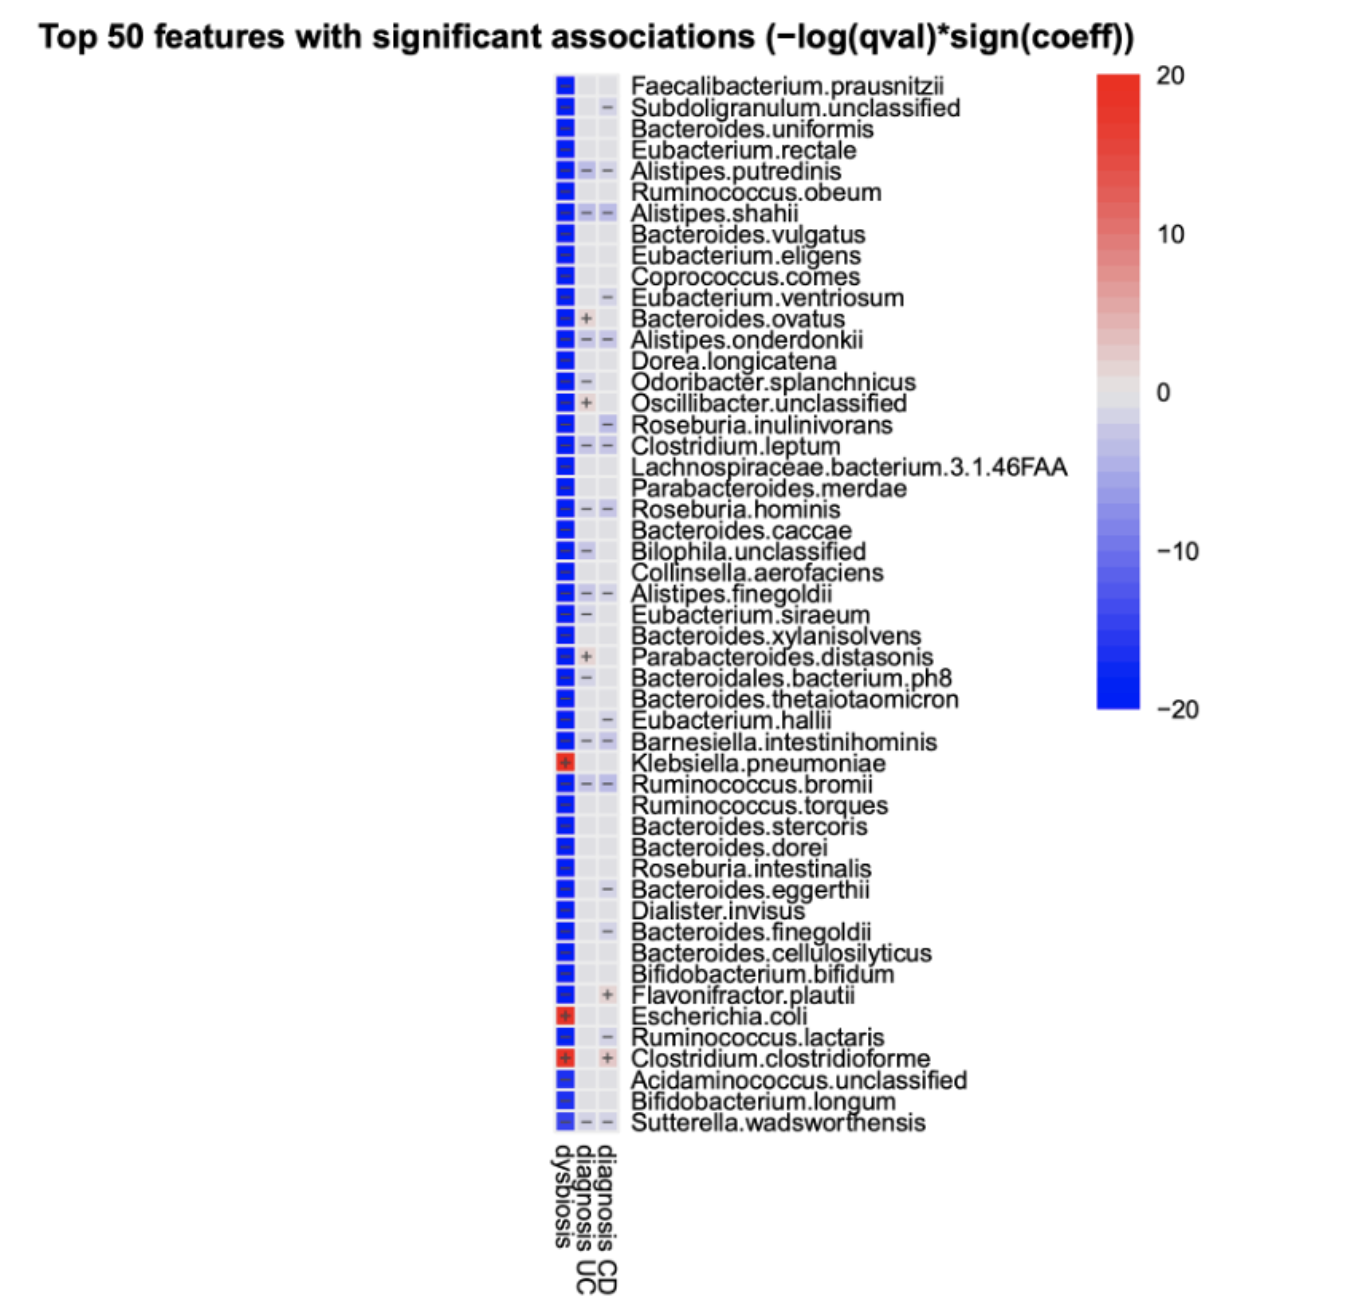

There are also two pdf files corresponding to each of the two variables included as fixed effects. - "diagnosis.pdf" - "dysbiosis.pdf"

Let's take a closer look at those dysbiosis-associated bacteria. Some examples: F. prausnitzii is a common short-chain fatty acid (SCFA) producer and known to be depleted in IBD patients. Further, specific oral isolates of K. pneumoniae from IBD patients have previously been shown to induce colitis in genetically susceptible mouse models [Koji Atarashi et al. 2017].

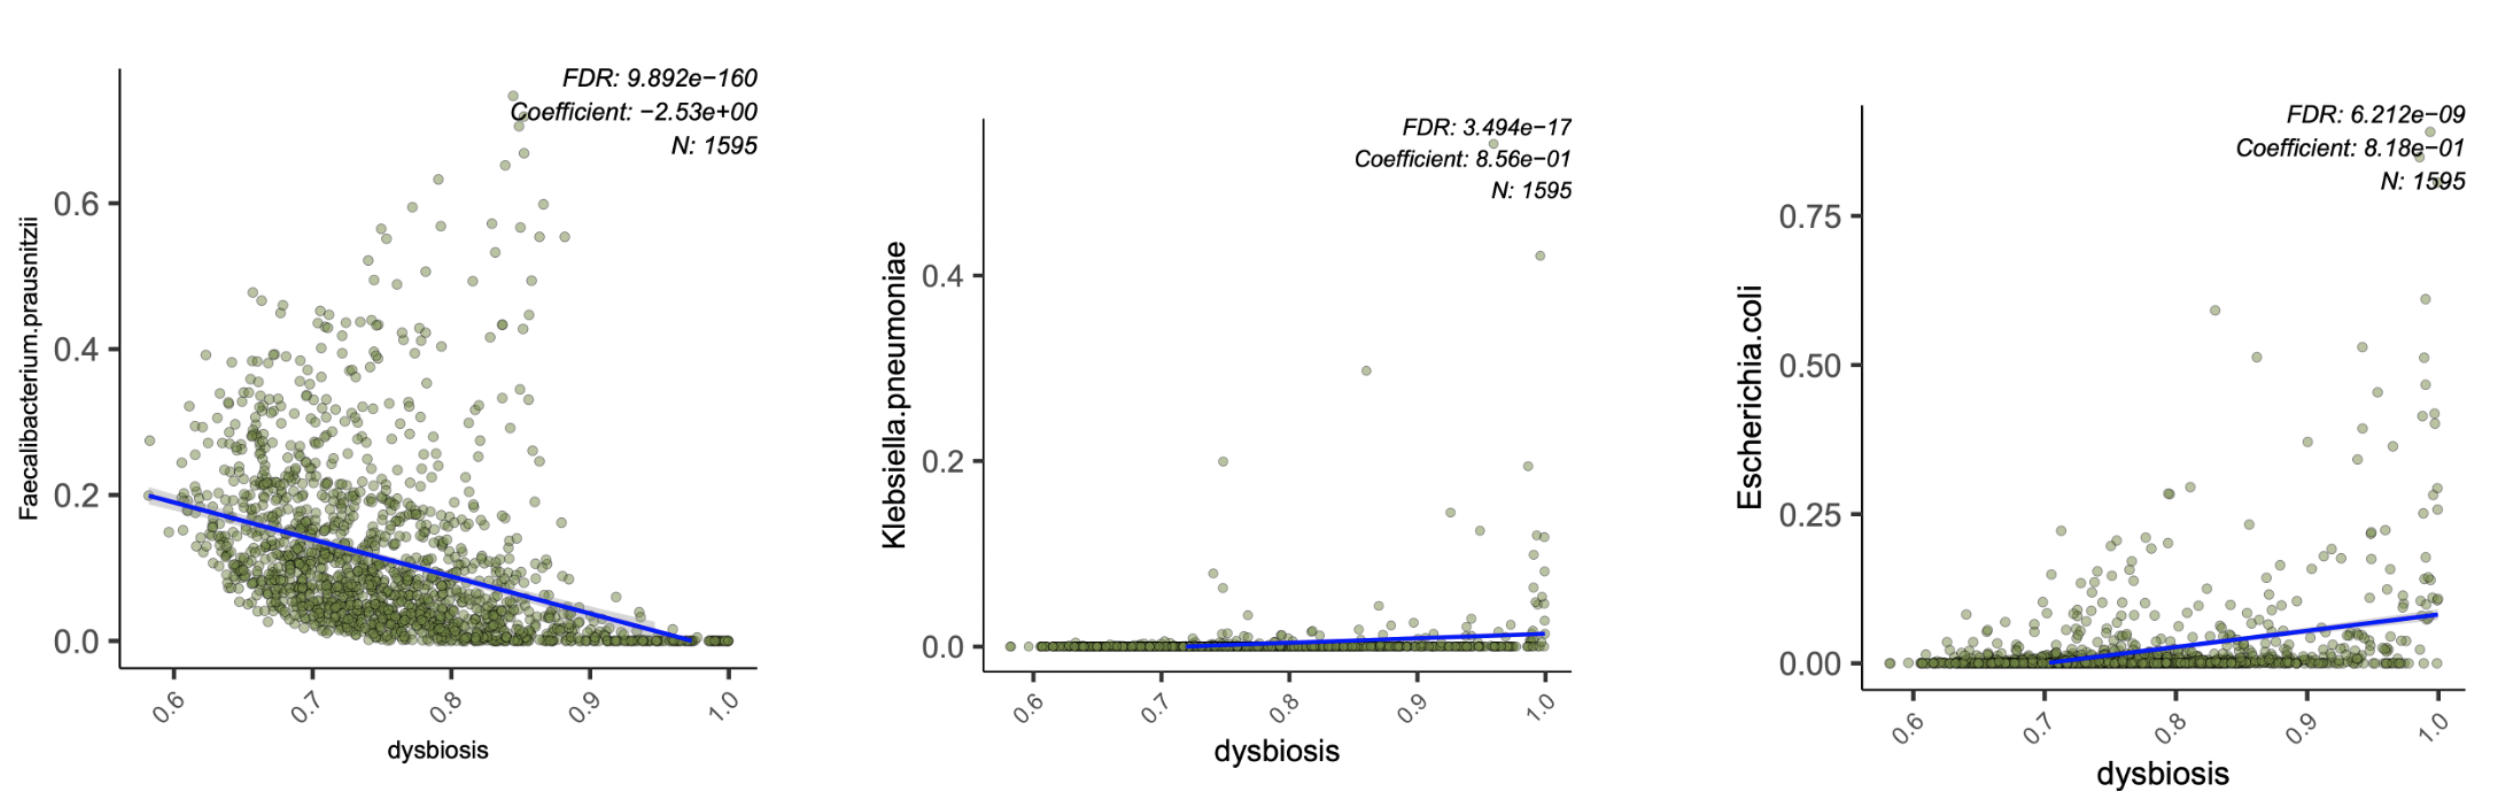

# Next we will further explore the data.
Let's take a another look at the metadata table:



In [7]:
head(df_input_metadata)


,site,age,diagnosis,subject,antibiotics,dysbiosis_binary,dysbiosis,dysbiosisnonIBD,dysbiosisUC,dysbiosisCD,collection
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>
CSM5FZ3N_P,Cedars-Sinai,43,CD,C3001,No,No,0.7923148,No,No,No,1
CSM5FZ3R_P,Cedars-Sinai,43,CD,C3001,No,No,0.8379234,No,No,No,2
CSM5FZ3T_P,Cedars-Sinai,76,CD,C3002,No,Yes,0.9242969,No,No,Yes,1
CSM5FZ3V_P,Cedars-Sinai,43,CD,C3001,No,No,0.8304005,No,No,No,4
CSM5FZ3X_P,Cedars-Sinai,76,CD,C3002,No,Yes,0.9109670,No,No,Yes,2
CSM5FZ3Z_P,Cedars-Sinai,76,CD,C3002,No,Yes,0.9122817,No,No,Yes,3


There are other potentially confounding variables that we haven't considered yet. For example, **antibiotics usage**, which is known to affect the microbiome.

Let's first check how many samples were collected during antibiotic usage.

In [8]:
table(df_input_metadata$antibiotics)


  No  Yes 
1437  158 

Now, we will check how many patients were taking antibiotics at some point during the study.

> Because patients may have multiple samples, we use the **unique()** function to get the unique entries.

In [9]:
# First, we will get all entries of the metadata table where antibiotics were taken
df_input_metadata_antibiotics_Yes = df_input_metadata %>% filter(antibiotics=="Yes")

# Extract the patient IDs from these entries
subject_id_lst = unique(df_input_metadata_antibiotics_Yes$subject)
print(length(subject_id_lst))
print(subject_id_lst)


[1] 51
 [1] "C3003" "C3008" "C3009" "C3010" "C3017" "C3024" "C3016" "C3027" "C3002"
[10] "C3031" "C3032" "C3034" "E5008" "E5009" "E5019" "H4006" "H4013" "H4016"
[19] "H4017" "H4024" "H4015" "H4030" "H4039" "H4042" "H4018" "H4035" "H4038"
[28] "M2025" "M2021" "M2028" "M2059" "M2071" "M2068" "M2064" "M2034" "M2069"
[37] "M2077" "M2097" "M2084" "P6009" "P6014" "P6010" "P6016" "P6025" "P6033"
[46] "P6013" "P6028" "P6018" "P6024" "P6005" "P6037"


# Now it is your turn to solve some tasks. See Tasks section below.

# Task section:


## Task 1: Include antibiotics usage and age as additional important covariates (fixed effects) and rerun MaAsLin2.

Hints:

> Which type of variable are we adding to the model (categorical or continuous)?

> Don't forget to choose your reference.

> How would you interpret your results?

### Take antibiotics usage and age as additional fixed effects into account and rerun MaAsLin2

Current model:

* Fixed effects

>> diagnosis [ref: nonIBD]

>> dysbiosis

>> antibiotics [ref: No]

>> age

Random effects

>> subject id

## Here is your solution

In [ ]:
# write the code for your solution here

## Task2: Consider variables with interactions

Hints:

> Build two variables called CD_dysbiosis and UC_dysbiosis as introduced in the previous section.

> Which type of variable are you adding to the model (categorical or continuous)?

> Don't forget to choose your reference.

> How would you interpret your results?

# Hint for task 2: Interactions between variables
Let's revisit the Linear Mixed Models and look at how to include interactions between variables in the model.

* X: vector of predictor variables [fixed effects in MaAsLin2]

* Beta: vector of coefficients of the fixed effect

* Z*u: term for random effects

* Epsilon: residuals

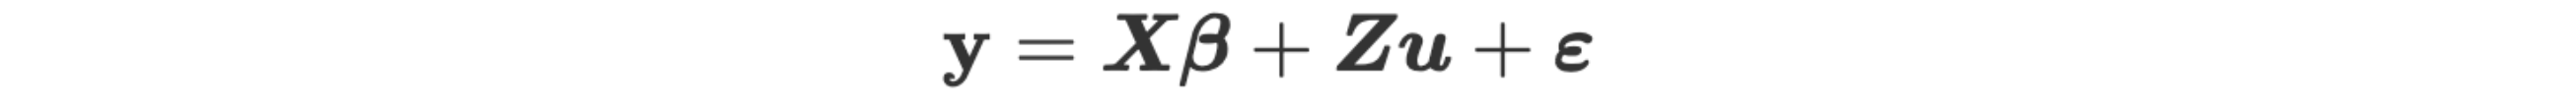

Sometimes the variables we want to include may not be independent of each other. In our example, the dysbiosis and diagnose variable are connected. We can build a variable to takes this interaction into account.

In [ ]:
df_input_metadata$CD_dysbiosis = (df_input_metadata$diagnosis == "CD") *
                                 df_input_metadata$dysbiosis
df_input_metadata$UC_dysbiosis = (df_input_metadata$diagnosis == "UC") *
                                 df_input_metadata$dysbiosis


## Here is your solution

In [ ]:
# write the code for your solution here: